Библиотеки

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from tensorflow.keras.layers import Layer, Dense, Embedding, LSTM
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


Загрузка и предобработка датасета

In [2]:
!wget -O dialogs.txt https://storage.yandexcloud.net/academy.ai/LLM/dialogs.txt

questions = []
answers = []

with open('dialogs.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line and '\t' in line:
            parts = line.split('\t')
            if len(parts) == 2:
                questions.append(parts[0].strip())
                answers.append(parts[1].strip())

print(f"Загружено {len(questions)} пар диалогов")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9?.!,¿]+", " ", text)
    text = re.sub(r"([?.!,¿])", r" \1 ", text)
    text = re.sub(r'[" "]+', " ", text)
    return text.strip()

questions = [clean_text(q) for q in questions]
answers = [clean_text(a) for a in answers]
answers = ["<start> " + a + " <end>" for a in answers]

print(f"Пример вопроса: {questions[0]}")
print(f"Пример ответа: {answers[0]}")

--2026-02-28 10:55:07--  https://storage.yandexcloud.net/academy.ai/LLM/dialogs.txt
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243904 (238K) [text/plain]
Saving to: ‘dialogs.txt’

dialogs.txt         100%[===================>] 238.19K   256KB/s    in 0.9s    

2026-02-28 10:55:09 (256 KB/s) - ‘dialogs.txt’ saved [243904/243904]

Загружено 3725 пар диалогов
Пример вопроса: hi , how are you doing ?
Пример ответа: <start> i m fine . how about yourself ? <end>


Создание токенизатора

In [3]:
VOCAB_SIZE = 10000
MAX_LEN_INP = 20
MAX_LEN_OUT = 25
EMBEDDING_DIM = 256
LSTM_UNITS = 512

tokenizer_inp = Tokenizer(num_words=VOCAB_SIZE, filters='', oov_token='<unk>')
tokenizer_inp.fit_on_texts(questions)
inp_sequences = tokenizer_inp.texts_to_sequences(questions)
inp_data = pad_sequences(inp_sequences, maxlen=MAX_LEN_INP, padding='post')

tokenizer_out = Tokenizer(num_words=VOCAB_SIZE, filters='', oov_token='<unk>')
tokenizer_out.fit_on_texts(answers)
out_sequences = tokenizer_out.texts_to_sequences(answers)
out_data = pad_sequences(out_sequences, maxlen=MAX_LEN_OUT, padding='post')

inp_word_index = tokenizer_inp.word_index
out_word_index = tokenizer_out.word_index
inp_vocab_size = min(VOCAB_SIZE, len(inp_word_index) + 1)
out_vocab_size = min(VOCAB_SIZE, len(out_word_index) + 1)

start_token = out_word_index.get('<start>', 1)
end_token = out_word_index.get('<end>', 2)

print(f"Размер словаря вопросов: {inp_vocab_size}")
print(f"Размер словаря ответов: {out_vocab_size}")

from sklearn.model_selection import train_test_split
inp_train, inp_val, out_train, out_val = train_test_split(
    inp_data, out_data, test_size=0.1, random_state=42
)

BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((inp_train, out_train))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((inp_val, out_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Размер словаря вопросов: 2343
Размер словаря ответов: 2400


Класс Attention (фиксированный выбор при создании)

In [4]:
class Attention(Layer):
    """
    Класс внимания. Метод внимания выбирается один раз при создании объекта
    и не может быть изменен во время обучения.
    """
    def __init__(self, units, method='luong_concat', name=None):
        super(Attention, self).__init__(name=name)
        self.units = units
        self.method = method

        # Создаем необходимые слои в зависимости от выбранного метода
        # Эти слои создаются один раз в конструкторе и фиксированы на всё обучение
        if method == 'bahdanau':
            self.W1 = Dense(units, name='bahdanau_W1')
            self.W2 = Dense(units, name='bahdanau_W2')
            self.V = Dense(1, name='bahdanau_V')

        elif method == 'luong_dot':
            # Для dot внимания не требуется дополнительных слоев
            pass

        elif method == 'luong_general':
            self.W = Dense(units, use_bias=False, name='luong_general_W')

        elif method == 'luong_concat':
            self.W = Dense(units, name='luong_concat_W')
            self.V = Dense(1, name='luong_concat_V')

        else:
            raise ValueError(f"Unknown method: {method}. Choose from: bahdanau, luong_dot, luong_general, luong_concat")

    def call(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: (batch_size, units)
        encoder_outputs: (batch_size, seq_len, units)
        """
        decoder_hidden_expanded = tf.expand_dims(decoder_hidden, 1)

        if self.method == 'bahdanau':
            # score = V^T * tanh(W1*decoder_hidden + W2*encoder_outputs)
            score = self.V(tf.nn.tanh(
                self.W1(decoder_hidden_expanded) + self.W2(encoder_outputs)
            ))
            score = tf.squeeze(score, -1)

        elif self.method == 'luong_dot':
            # score = decoder_hidden^T * encoder_outputs
            score = tf.matmul(decoder_hidden_expanded, encoder_outputs, transpose_b=True)
            score = tf.squeeze(score, 1)

        elif self.method == 'luong_general':
            # score = decoder_hidden^T * W * encoder_outputs
            transformed_enc = self.W(encoder_outputs)
            score = tf.matmul(decoder_hidden_expanded, transformed_enc, transpose_b=True)
            score = tf.squeeze(score, 1)

        elif self.method == 'luong_concat':
            # score = V^T * tanh(W * [decoder_hidden; encoder_outputs])
            decoder_repeated = tf.repeat(decoder_hidden_expanded, tf.shape(encoder_outputs)[1], axis=1)
            concat = tf.concat([decoder_repeated, encoder_outputs], axis=-1)
            score = self.V(tf.nn.tanh(self.W(concat)))
            score = tf.squeeze(score, -1)

        attention_weights = tf.nn.softmax(score, axis=-1)
        context_vector = tf.reduce_sum(
            tf.expand_dims(attention_weights, -1) * encoder_outputs, axis=1
        )

        return context_vector, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'method': self.method
        })
        return config


Энкодер

In [5]:
class Encoder(Layer):
    def __init__(self, vocab_size, embedding_dim, units, name=None):
        super(Encoder, self).__init__(name=name)
        self.units = units
        self.embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)
        self.lstm = LSTM(units, return_sequences=True, return_state=True)

    def call(self, inputs):
        x = self.embedding(inputs)
        outputs, state_h, state_c = self.lstm(x)
        return outputs, state_h, state_c

Декодер

In [6]:
class Decoder(Layer):
    def __init__(self, vocab_size, embedding_dim, units, attention_method='luong_concat', name=None):
        super(Decoder, self).__init__(name=name)

        # ВАЖНО: Механизм внимания создается здесь один раз
        # и остается неизменным для всего обучения
        self.attention = Attention(units, method=attention_method)

        self.units = units
        self.embedding = Embedding(vocab_size, embedding_dim, mask_zero=True)
        self.lstm = LSTM(units, return_sequences=True, return_state=True)
        self.fc = Dense(vocab_size)

    def call(self, inputs, hidden_state, cell_state, encoder_outputs):
        x = self.embedding(inputs)
        lstm_output, hidden_state, cell_state = self.lstm(x, initial_state=[hidden_state, cell_state])

        # Используем фиксированный механизм внимания
        context_vector, attention_weights = self.attention(hidden_state, encoder_outputs)

        context_expanded = tf.expand_dims(context_vector, 1)
        concat = tf.concat([lstm_output, context_expanded], axis=-1)

        output = self.fc(concat)
        output = tf.squeeze(output, axis=1)

        return output, hidden_state, cell_state, attention_weights

 Основная Seq2Seq модель (фиксированный выбор внимания)

In [17]:

class Seq2Seq(Model):
    def __init__(self, inp_vocab_size, out_vocab_size, embedding_dim, units,
                 attention_method='luong_concat'):
        super(Seq2Seq, self).__init__()

        self.attention_method = attention_method
        self.encoder = Encoder(inp_vocab_size, embedding_dim, units)
        self.decoder = Decoder(out_vocab_size, embedding_dim, units,
                               attention_method=attention_method)

    def call(self, data, training=False):
        inp, out = data

        # Прямой проход через энкодер
        encoder_outputs, hidden_state, cell_state = self.encoder(inp)

        batch_size = tf.shape(out)[0]
        target_len = tf.shape(out)[1]

        # Инициализируем вход декодера как токен <start>
        decoder_input = tf.expand_dims([start_token] * batch_size, 1)

        # ИСПРАВЛЕНИЕ: Используем простой Python цикл вместо tf.while_loop
        # для совместимости с динамическими размерами
        outputs_list = []

        for t in range(1, target_len):
            # Прямой проход декодера
            decoder_output, hidden_state, cell_state, _ = self.decoder(
                decoder_input, hidden_state, cell_state, encoder_outputs
            )

            # Сохраняем выход
            outputs_list.append(decoder_output)

            # Следующий вход для учителя (teacher forcing)
            decoder_input = tf.expand_dims(out[:, t], 1)

        # Стек из списка
        outputs = tf.stack(outputs_list, axis=1)  # (batch_size, target_len-1, vocab_size)

        return outputs

    def predict(self, inp_sequence):
        """Генерация ответа для одного вопроса"""
        encoder_outputs, hidden_state, cell_state = self.encoder(tf.expand_dims(inp_sequence, 0))

        decoder_input = tf.expand_dims([start_token], 0)
        result = []
        attention_weights_all = []

        for t in range(MAX_LEN_OUT):
            decoder_output, hidden_state, cell_state, attention_weights = self.decoder(
                decoder_input, hidden_state, cell_state, encoder_outputs
            )

            attention_weights_all.append(attention_weights[0].numpy())

            predicted_id = tf.argmax(decoder_output, axis=-1).numpy()[0]
            result.append(predicted_id)

            if predicted_id == end_token:
                break

            decoder_input = tf.expand_dims([predicted_id], 0)

        return result, attention_weights_all

    def get_attention_method(self):
        return self.attention_method

Функция потерь

In [8]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

Функция тестирования

In [9]:
def test_model(model, question):
    """Тестирование модели на одном вопросе"""
    question_clean = clean_text(question)
    seq = tokenizer_inp.texts_to_sequences([question_clean])
    padded = pad_sequences(seq, maxlen=MAX_LEN_INP, padding='post')

    result_ids, attention_weights = model.predict(padded[0])

    result_words = []
    for idx in result_ids:
        if idx == end_token:
            break
        if idx > 0 and idx < len(tokenizer_out.index_word):
            result_words.append(tokenizer_out.index_word[idx])

    return ' '.join(result_words), attention_weights

Функция визуализации внимания

In [10]:
def plot_attention(question, answer, attention_weights, attention_method):
    """Визуализация матрицы внимания"""
    question_tokens = question.split()
    answer_tokens = answer.split()

    if answer_tokens and answer_tokens[0] == '<start>':
        answer_tokens = answer_tokens[1:]
    if answer_tokens and answer_tokens[-1] == '<end>':
        answer_tokens = answer_tokens[:-1]

    attention_weights = attention_weights[:len(answer_tokens)]
    attention_matrix = np.array(attention_weights)
    attention_matrix = attention_matrix[:, :len(question_tokens)]

    plt.figure(figsize=(12, 8))
    sns.heatmap(attention_matrix, xticklabels=question_tokens, yticklabels=answer_tokens,
                cmap='Blues', cbar=True, annot=False)
    plt.xlabel('Вопрос')
    plt.ylabel('Ответ')
    plt.title(f'Визуализация внимания ({attention_method})')
    plt.tight_layout()
    plt.show()

СОЗДАНИЕ МОДЕЛИ - ВЫБОР МЕХАНИЗМА ВНИМАНИЯ ЗДЕСЬ!

Нужно выбрать один из методов:
'bahdanau', 'luong_dot', 'luong_general', 'luong_concat'


In [18]:

ATTENTION_METHOD = 'luong_concat'  # 'bahdanau', 'luong_dot', 'luong_general', 'luong_concat'

print(f"Создание модели с механизмом внимания: {ATTENTION_METHOD}")

model = Seq2Seq(
    inp_vocab_size=inp_vocab_size,
    out_vocab_size=out_vocab_size,
    embedding_dim=EMBEDDING_DIM,
    units=LSTM_UNITS,
    attention_method=ATTENTION_METHOD
)

# Строим модель
dummy_input = tf.zeros((1, MAX_LEN_INP), dtype=tf.int32)
dummy_output = tf.zeros((1, MAX_LEN_OUT), dtype=tf.int32)
_ = model((dummy_input, dummy_output), training=False)

optimizer = tf.keras.optimizers.Adam()
train_loss = tf.keras.metrics.Mean(name='train_loss')
val_loss = tf.keras.metrics.Mean(name='val_loss')

print(f"Метод внимания: {model.get_attention_method()}")
print(f"Всего параметров: {model.count_params():,}")
print("\nСтруктура модели:")
model.summary()

Создание модели с механизмом внимания: luong_concat


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1474: UserWarning: Layer 'seq2_seq_3' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: '''SymbolicTensor' object cannot be interpreted as an integer''
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'seq2_seq_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. T

Метод внимания: luong_concat
Всего параметров: 7,349,345

Структура модели:


Model: "seq2_seq_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_3 (Encoder)             │ ?                      │     2,174,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_3 (Decoder)             │ ?                      │     5,174,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,349,345 (28.04 MB)

 Trainable params: 7,349,345 (28.04 MB)

 Non-trainable params: 0 (0.00 B)

Обучение модели

In [20]:

EPOCHS = 15

# Убираем @tf.function для совместимости
def train_step(inp, out):
    with tf.GradientTape() as tape:
        predictions = model((inp, out), training=True)
        loss = loss_function(out[:, 1:], predictions)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    train_loss(loss)

def val_step(inp, out):
    predictions = model((inp, out), training=False)
    loss = loss_function(out[:, 1:], predictions)
    val_loss(loss)

history_train = []
history_val = []

for epoch in range(EPOCHS):
    train_loss.reset_state()
    val_loss.reset_state()

    # Training
    for step, (inp, out) in enumerate(train_dataset):
        train_step(inp, out)
        if step % 50 == 0:
            print(f'Epoch {epoch+1}, Step {step}, Loss: {train_loss.result():.4f}')

    # Validation
    for inp, out in val_dataset:
        val_step(inp, out)

    # Сохраняем результаты
    train_loss_value = train_loss.result().numpy()
    val_loss_value = val_loss.result().numpy()

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss_value:.4f}, Val Loss: {val_loss_value:.4f}')

    history_train.append(train_loss_value)
    history_val.append(val_loss_value)

print(f"\nОбучение завершено! Финальная loss на тренировке: {history_train[-1]:.4f}")

Epoch 1, Step 0, Loss: 2.8477
Epoch 1, Step 50, Loss: 2.2087
Epoch 1/15, Train Loss: 2.1964, Val Loss: 1.8794
Epoch 2, Step 0, Loss: 1.8000
Epoch 2, Step 50, Loss: 1.8373
Epoch 2/15, Train Loss: 1.8373, Val Loss: 1.7877
Epoch 3, Step 0, Loss: 1.8924


ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 241, in while_loop_v2
    return while_loop(  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 492, in while_loop
    nest.assert_same_structure(loop_var_structure, list(loop_vars))  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/ops/while_loop.py", line 479, in <lambda>
    body = lambda i, lv: (i + 1, orig_body(*lv))  File "/tmp/ipython-input-671/2585635346.py", line 50, in loop_body
    return t + 1, next_decoder_input, new_hidden_state, new_cell_state, outputs  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(f

Epoch 3, Step 50, Loss: 1.7290
Epoch 3/15, Train Loss: 1.7366, Val Loss: 1.7164
Epoch 4, Step 0, Loss: 1.5980
Epoch 4, Step 50, Loss: 1.6451
Epoch 4/15, Train Loss: 1.6418, Val Loss: 1.6639
Epoch 5, Step 0, Loss: 1.6230
Epoch 5, Step 50, Loss: 1.5697
Epoch 5/15, Train Loss: 1.5737, Val Loss: 1.6253
Epoch 6, Step 0, Loss: 1.6990
Epoch 6, Step 50, Loss: 1.5062
Epoch 6/15, Train Loss: 1.5053, Val Loss: 1.5920
Epoch 7, Step 0, Loss: 1.4392
Epoch 7, Step 50, Loss: 1.4365
Epoch 7/15, Train Loss: 1.4425, Val Loss: 1.5711
Epoch 8, Step 0, Loss: 1.4340
Epoch 8, Step 50, Loss: 1.3787
Epoch 8/15, Train Loss: 1.3782, Val Loss: 1.5553
Epoch 9, Step 0, Loss: 1.3003
Epoch 9, Step 50, Loss: 1.3197
Epoch 9/15, Train Loss: 1.3166, Val Loss: 1.5520
Epoch 10, Step 0, Loss: 1.1584
Epoch 10, Step 50, Loss: 1.2608
Epoch 10/15, Train Loss: 1.2602, Val Loss: 1.5544
Epoch 11, Step 0, Loss: 1.1157
Epoch 11, Step 50, Loss: 1.2015
Epoch 11/15, Train Loss: 1.2006, Val Loss: 1.5650
Epoch 12, Step 0, Loss: 1.1364
Epo

График обучения

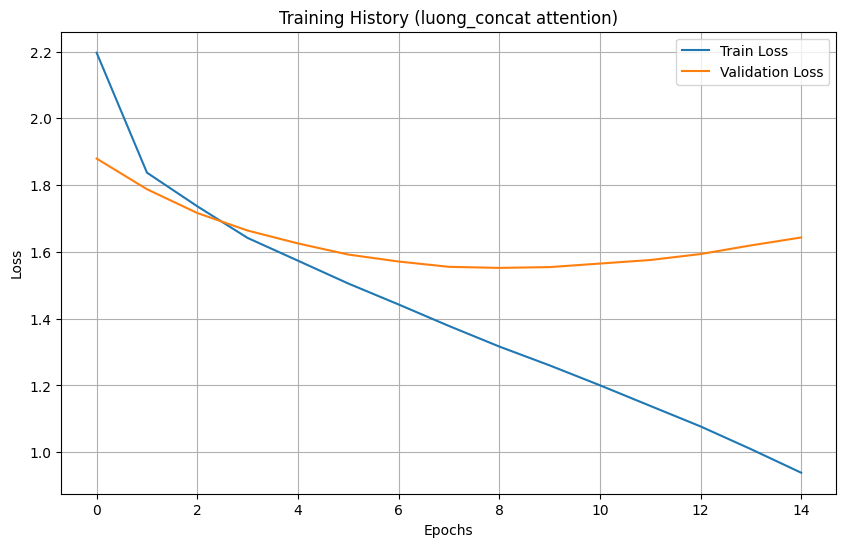

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(history_train, label='Train Loss')
plt.plot(history_val, label='Validation Loss')
plt.title(f'Training History ({model.get_attention_method()} attention)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Тестирование и визуализация


Тестирование модели с механизмом: luong_concat

Q: hi, how are you?
A: i m going to be a restaurant .

Q: what school do you go to?
A: i m going to pcc .

Q: do you like it there?
A: yes , it s april 22 .

Q: good luck with school
A: drink drink time you re hot .

Визуализация внимания для вопроса: 'hi, how are you?'
Сгенерированный ответ: 'i m going to be a restaurant .'


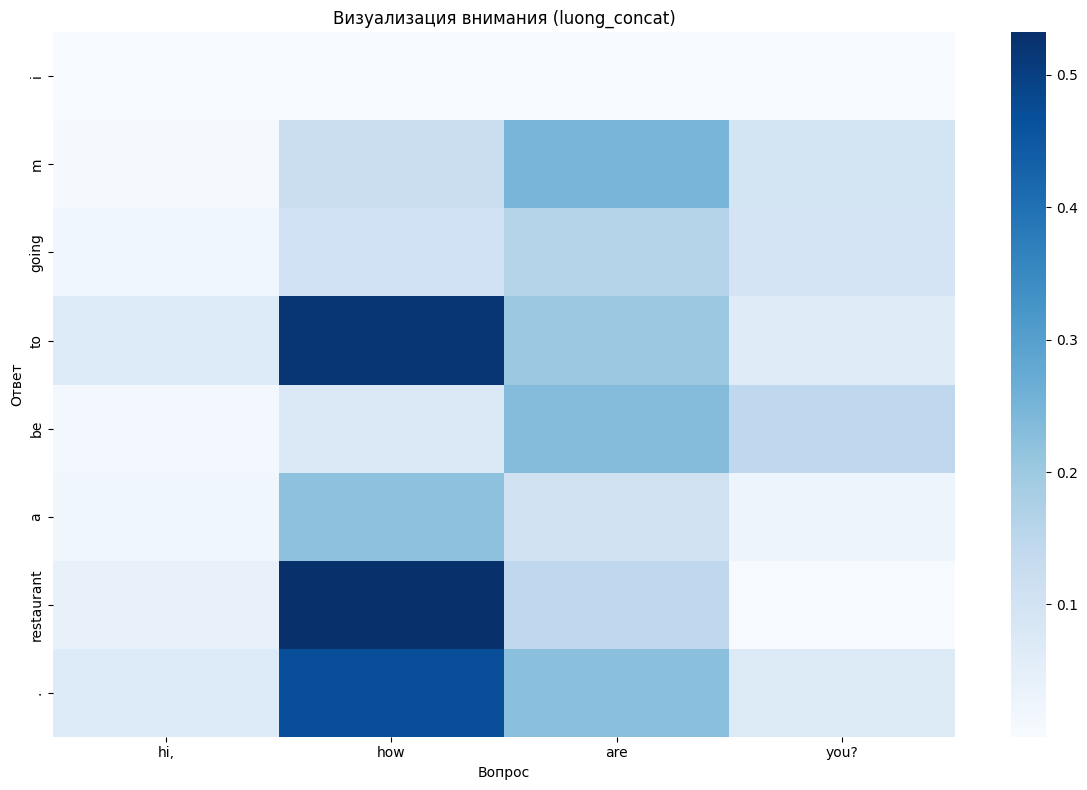

In [22]:
test_questions = [
    "hi, how are you?",
    "what school do you go to?",
    "do you like it there?",
    "good luck with school"
]

print(f"\nТестирование модели с механизмом: {model.get_attention_method()}")
print("=" * 60)

for q in test_questions:
    answer, _ = test_model(model, q)
    print(f"\nQ: {q}")
    print(f"A: {answer}")

# Визуализация для первого вопроса
q = test_questions[0]
answer, attention_weights = test_model(model, q)
print(f"\nВизуализация внимания для вопроса: '{q}'")
print(f"Сгенерированный ответ: '{answer}'")
plot_attention(q, answer, attention_weights, model.get_attention_method())
